# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Iris Dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["Species"] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


# Display Dataset Information

In [3]:
print("Shape of Dataset:", X.shape)

print("\nFeature Names:")
print(feature_names)

print("\nFirst Five Rows:")
print(df.head())


Shape of Dataset: (150, 4)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First Five Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


# Standardize the Data

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("First Five Standardized Rows:\n")
print(X_scaled[:5])

First Five Standardized Rows:

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


# Compute the Covariance Matrix

In [5]:
cov_matrix = np.cov(X_scaled.T)

print("Covariance Matrix:\n")
print(cov_matrix)

Covariance Matrix:

[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


# Compute Eigenvalues and Eigenvectors

In [6]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n")
print(eigen_values)

print("\nEigenvectors:\n")
print(eigen_vectors)

Eigenvalues:

[2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors:

[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


# Sort Eigenvalues and Eigenvectors

In [7]:
sorted_index = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]

print("Sorted Eigenvalues:\n")
print(eigen_values)

Sorted Eigenvalues:

[2.93808505 0.9201649  0.14774182 0.02085386]


# Calculate Explained Variance Ratio

In [8]:
explained_variance_ratio = eigen_values / np.sum(eigen_values)

print("Explained Variance Ratio:\n")
print(explained_variance_ratio)

Explained Variance Ratio:

[0.72962445 0.22850762 0.03668922 0.00517871]


# Calculate Cumulative Variance

In [9]:
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Cumulative Variance:\n")
print(cumulative_variance)

Cumulative Variance:

[0.72962445 0.95813207 0.99482129 1.        ]


# Select Top 2 Principal Components

In [10]:
k = 2

projection_matrix = eigen_vectors[:, :k]

print("Projection Matrix:\n")
print(projection_matrix)

Projection Matrix:

[[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]


# Project the Data

In [11]:
X_pca = np.dot(X_scaled, projection_matrix)

print("Shape after PCA:", X_pca.shape)

print("\nFirst Five PCA Values:\n")
print(X_pca[:5])

Shape after PCA: (150, 2)

First Five PCA Values:

[[-2.26470281 -0.4800266 ]
 [-2.08096115  0.67413356]
 [-2.36422905  0.34190802]
 [-2.29938422  0.59739451]
 [-2.38984217 -0.64683538]]


# Perform PCA Using Scikit-learn

In [12]:
pca = PCA(n_components=2)

X_pca_sklearn = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.72962445 0.22850762]


# Compare Manual PCA and Scikit-learn PCA

In [13]:
print("Manual PCA Shape:", X_pca.shape)
print("Scikit-learn PCA Shape:", X_pca_sklearn.shape)

Manual PCA Shape: (150, 2)
Scikit-learn PCA Shape: (150, 2)


# Create a PCA DataFrame

In [14]:
pca_df = pd.DataFrame(
    X_pca_sklearn,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Species"] = y

print(pca_df.head())

   Principal Component 1  Principal Component 2  Species
0              -2.264703               0.480027        0
1              -2.080961              -0.674134        0
2              -2.364229              -0.341908        0
3              -2.299384              -0.597395        0
4              -2.389842               0.646835        0


# Visualize PCA

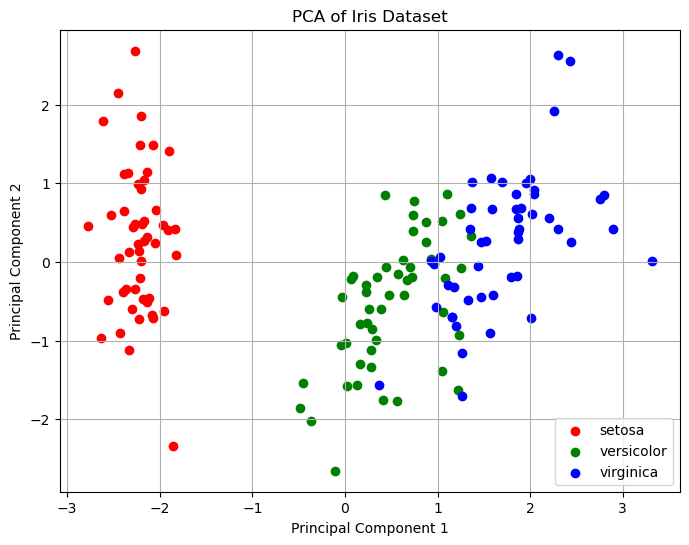

In [15]:
plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']
labels = iris.target_names

for i in range(3):
    plt.scatter(
        X_pca_sklearn[y == i, 0],
        X_pca_sklearn[y == i, 1],
        color=colors[i],
        label=labels[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.grid(True)

plt.show()

# Print Final Results

In [16]:
print("Original Shape :", X.shape)

print("Reduced Shape :", X_pca_sklearn.shape)

print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Captured")
print(np.sum(pca.explained_variance_ratio_))

Original Shape : (150, 4)
Reduced Shape : (150, 2)

Explained Variance Ratio
[0.72962445 0.22850762]

Total Variance Captured
0.9581320720000164


# IMPORT LIBRARIES

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# STEP 1: Load the dataset

In [37]:
wine = load_wine()

X = wine.data                  # shape (178, 13)
y = wine.target                # class labels (0, 1, 2)
feature_names = wine.feature_names

print("Original data shape:", X.shape)
print("Feature names:")
print(feature_names)


Original data shape: (178, 13)
Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


# STEP 2: Standardize the data

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling (~0):")
print(np.round(X_scaled.mean(axis=0), 3))

print("\nStd after scaling (~1):")
print(np.round(X_scaled.std(axis=0), 3))



Mean after scaling (~0):
[ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

Std after scaling (~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# STEP 3A: PCA FROM SCRATCH (NumPy)

In [39]:
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# Covariance Matrix
cov_matrix = np.cov(X_scaled.T)

print("\nCovariance Matrix:")
print(np.round(cov_matrix, 3))

# Eigenvalues and Eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Sort Eigenvalues
sorted_idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("\nEigenvalues:")
print(np.round(eigen_values, 3))

# Explained Variance Ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)

print("\nExplained Variance Ratio:")
print(np.round(explained_variance_ratio, 3))

print("\nCumulative Variance (First 2 Components):")
print(np.round(np.sum(explained_variance_ratio[:2]), 3))

# Projection Matrix
k = 2
projection_matrix = eigen_vectors[:, :k]

# Project Data
X_pca_scratch = X_scaled.dot(projection_matrix)

print("\nTransformed Data Shape (Scratch):")
print(X_pca_scratch.shape)


PCA FROM SCRATCH

Covariance Matrix:
[[ 1.006  0.095  0.213 -0.312  0.272  0.291  0.238 -0.157  0.137  0.549
  -0.072  0.073  0.647]
 [ 0.095  1.006  0.165  0.29  -0.055 -0.337 -0.413  0.295 -0.222  0.25
  -0.564 -0.371 -0.193]
 [ 0.213  0.165  1.006  0.446  0.288  0.13   0.116  0.187  0.01   0.26
  -0.075  0.004  0.225]
 [-0.312  0.29   0.446  1.006 -0.084 -0.323 -0.353  0.364 -0.198  0.019
  -0.276 -0.278 -0.443]
 [ 0.272 -0.055  0.288 -0.084  1.006  0.216  0.197 -0.258  0.238  0.201
   0.056  0.066  0.396]
 [ 0.291 -0.337  0.13  -0.323  0.216  1.006  0.869 -0.452  0.616 -0.055
   0.436  0.704  0.501]
 [ 0.238 -0.413  0.116 -0.353  0.197  0.869  1.006 -0.541  0.656 -0.173
   0.547  0.792  0.497]
 [-0.157  0.295  0.187  0.364 -0.258 -0.452 -0.541  1.006 -0.368  0.14
  -0.264 -0.506 -0.313]
 [ 0.137 -0.222  0.01  -0.198  0.238  0.616  0.656 -0.368  1.006 -0.025
   0.297  0.522  0.332]
 [ 0.549  0.25   0.26   0.019  0.201 -0.055 -0.173  0.14  -0.025  1.006
  -0.525 -0.431  0.318]
 [-0.

# STEP 3B: PCA USING SCIKIT-LEARN

In [40]:
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)

X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(np.round(pca.explained_variance_ratio_, 3))

print("\nCumulative Variance:")
print(np.round(np.sum(pca.explained_variance_ratio_), 3))

print("\nTransformed Data Shape:")
print(X_pca_sklearn.shape)


PCA USING SCIKIT-LEARN

Explained Variance Ratio:
[0.362 0.192]

Cumulative Variance:
0.554

Transformed Data Shape:
(178, 2)


# STEP 4: Visualization

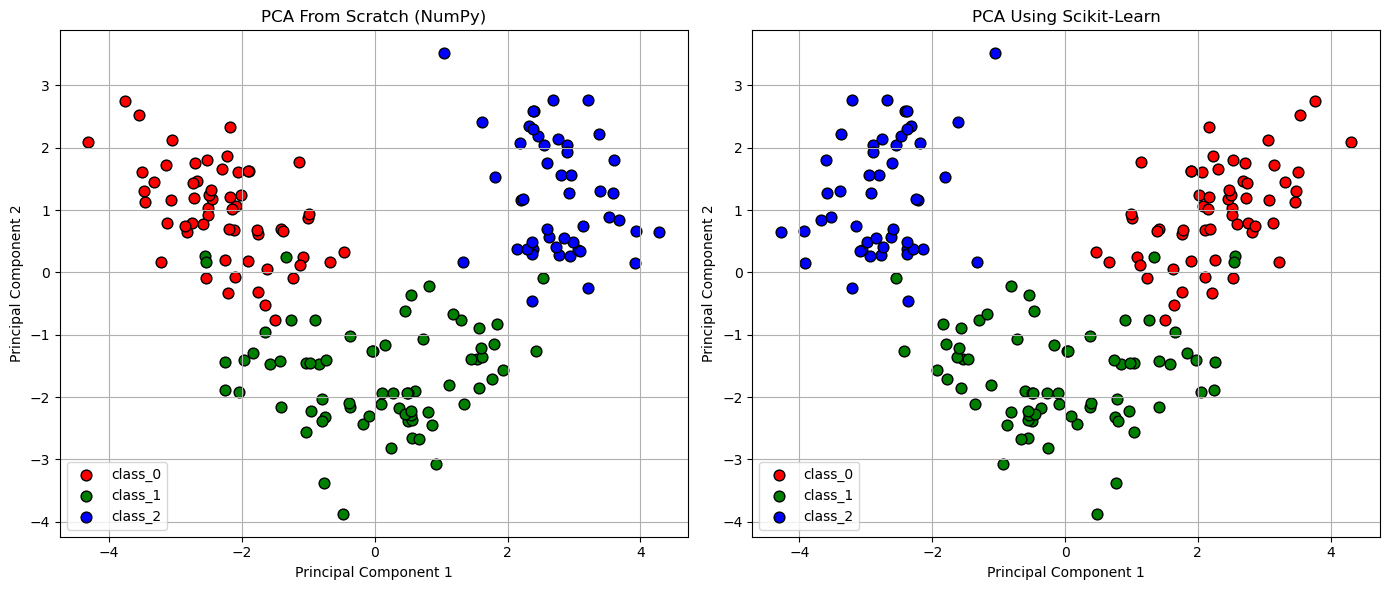


Plot saved as pca_wine_result.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["red", "green", "blue"]
target_names = wine.target_names

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch (NumPy)", "PCA Using Scikit-Learn"]
):

    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0],
            data[y == i, 1],
            color=colors[i],
            label=target_name,
            edgecolor="black",
            s=60
        )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("pca_wine_result.png", dpi=150)
plt.show()

print("\nPlot saved as pca_wine_result.png")

# STEP 5: Sanity Check

In [42]:
assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"

print("\nSanity Check Passed!")
print("Scratch implementation matches scikit-learn.")


Sanity Check Passed!
Scratch implementation matches scikit-learn.
